# Cellular Automata

[Moreno Marzolla](https://www.moreno.marzolla.name)

Written in June 2026.

Last modified June 2026.

---

A Cellular Automaton (CA) is a mathematical model of computation that consists of a regular lattice of cells that can be in any of $k$ different states. Each cell has a _neighborhood_ that includes nearby cells; an _update function_ maps the states of the neighborhood into a new state of the central cell. 

In this notebook we consider a restricted class of CA, namely _elementary cellular automata_, that have the following properties:

- An array of cells $c_0, \ldots, c_{n-1}$;
- Each cell can have $k=2$ states;
- The neighborhood is composed of $r=1$ adjacent cells on each side.

The update function for cell $c_i$ maps the triplet $c_{i-1}, c_i, c_{i+1}$ into a new state $c'_i$ of the central cell. Cyclic boundary conditions ensure that each cell has both a left and right neighbor. State updates are _synchronous_, meaning that at each timestep, all cells  compute their new state and then apply the update.

There is a limited number of different elementary CA; specifically, there are $2^3 = 8$ different configurations of the neighborhood, and for each configuration we can pick any of 2 different states for the central cell. Therefore, there are $2^8 = 256$ different set of rules. 

The update rule of a CA can be tabulated as follows: list all possible configurations of three adjacent cells as binary numbers; the configurations are sorted according to theie decimal representation.:

- 000
- 001
- 010
- 011
- 100
- 101
- 110
- 111

Then for each tripled, define the new state of the central cell, e.g.:

- 000 -> 0
- 001 -> 1
- 010 -> 1
- 011 -> 1
- 100 -> 1
- 101 -> 0
- 110 -> 0
- 111 -> 0

Now, write down the column of the new states (the lsb is the top one, the msb is the bottom one): 00011110, which is the base 2 representation of 30. Hence, the rule above is "rule 30".

This is called the _Wolfram code_, and allows the description of the rules of any of the elementary CA with a single decimal number in the rance $0, \ldots, 255$. The utility function `rule(r)` accepts the Wolfram code of a rule, and returns the array of new states (note that the array is _in reverse_).

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['image.cmap'] = 'binary'
plt.rcParams['figure.dpi'] = 300
import numpy as np
rng = np.random.RandomState(42)

def rule(r):
    '''
    Given an integer 0 <= r < 256, return an array of length 8
    with the new states according to Wolfram numbering.
    '''
    result = np.zeros(8, int)
    idx = 0
    while (r > 0):
        result[idx] = (r & 1)
        idx = idx + 1
        r = r >> 1
    return result

print(rule(30))

[0 1 1 1 1 0 0 0]


We define function `evolve(state, rule)` that takes as parameters the current state of the CA (binary array of length $n$), and a binary array of length $8$ representing the update function, and returns a new binary array of length $n$ with the updated states according to the rule.

In [2]:
def evolve(state, rule):
    '''
    Given the current state (array of length n) and the rule array (array of length 8), return
    the next state.
    '''
    L = np.roll(state,1)  # left
    C = state             # center
    R = np.roll(state,-1) # right
    result = np.zeros(len(state),int)
    for i in range(0,len(state)):
        result[i] = rule[L[i]*4 + C[i]*2 + R[i]]
    return result

print(evolve([0,0,0,1,0,0,0,0], rule(30)))

[0 0 1 1 1 0 0 0]


We now define a function `CA(r, initial_state, n)` that takes as parameters:

- The integer Wolfram code $r$ of an elementary CA ($0 \ldots r \ldots 255$);
- The initial state of the CA (binary array of length $k$);
- A number of steps $n$ to simulate.

The function returns a $n$ times $k$ binary matrix, where the first row at the top is the initial state, the the $n-1$ rows below are the updated states at each subsequent timestep.

In [3]:
def CA(r, initial_state, n):
    '''
    Return a matrix of n rows with the evolution of
    rule-r CA starting from state `initial_State`.
    Cyclic boundary conditions are assumed.
    '''
    width = len(initial_state)
    result = np.zeros([n,width], int)
    result[0,:] = initial_state
    rr = rule(r)
    for i in range(1,n):
        result[i,:] = evolve(result[i-1,:],rr)
    return result

CA(30, [0, 0, 0, 1, 0, 0, 0, 0], 5)

array([[0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 0],
       [1, 1, 0, 1, 1, 1, 1, 0],
       [1, 0, 0, 1, 0, 0, 0, 0]])

The evolution of the CA can be displayed graphically using the `plt.matshot()` function. What we get is a sort of "static movie" of the time evolution of the CA, where each row from top to bottom represents a single frame of the movie, i.e., the state at each timestep.

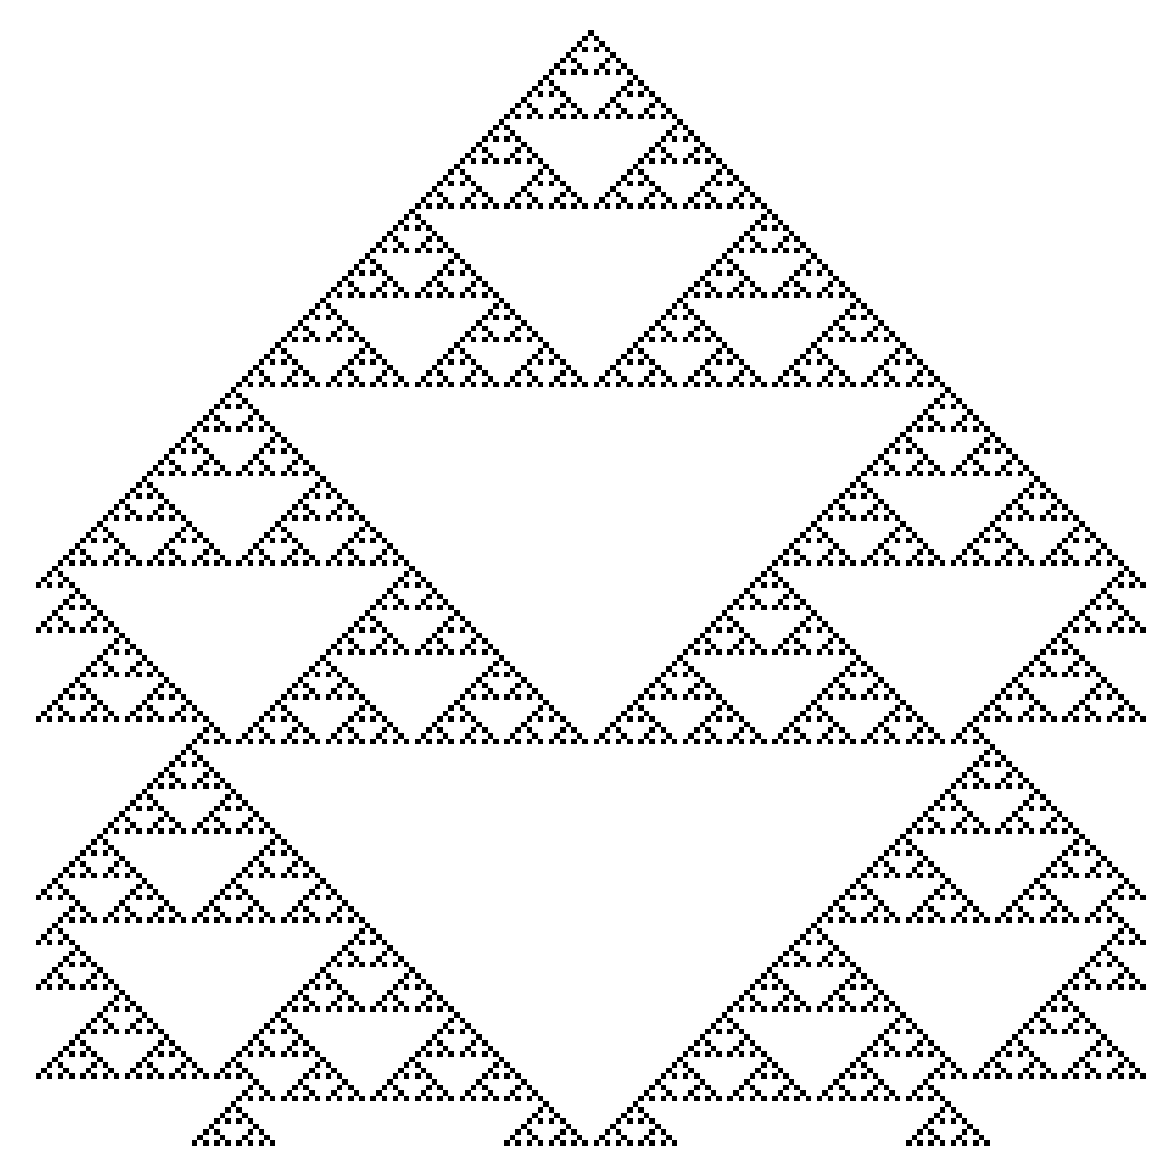

In [4]:
n = 200
initial_state = np.zeros(n)
initial_state[n//2] = 1
plt.matshow(CA(82, initial_state, n))
plt.axis(False)
plt.show()

In [5]:
def plot_CA_class(rule_list, class_label):
    '''
    Source: https://matplotlib.org/matplotblog/posts/elementary-cellular-automata/
    '''
    #rng = np.random.RandomState(seed=0)
    fig, axs = plt.subplots(1, len(rule_list),figsize=(10, 3.5), constrained_layout=True)
    initial = rng.randint(0, 2, 100)

    for i, ax in enumerate(axs.ravel()):
        data = CA(rule_list[i], initial, 100)
        ax.set_title(f'Rule {rule_list[i]}')
        ax.matshow(data)
        ax.axis(False)

    fig.suptitle(class_label, fontsize=16)

    return fig, ax

# A gallery of elementary CA

Since there are only 256 elementary CA, we can draw a "family portrait" showing their evolution starting witn an initial state with only a single black cell at the center.

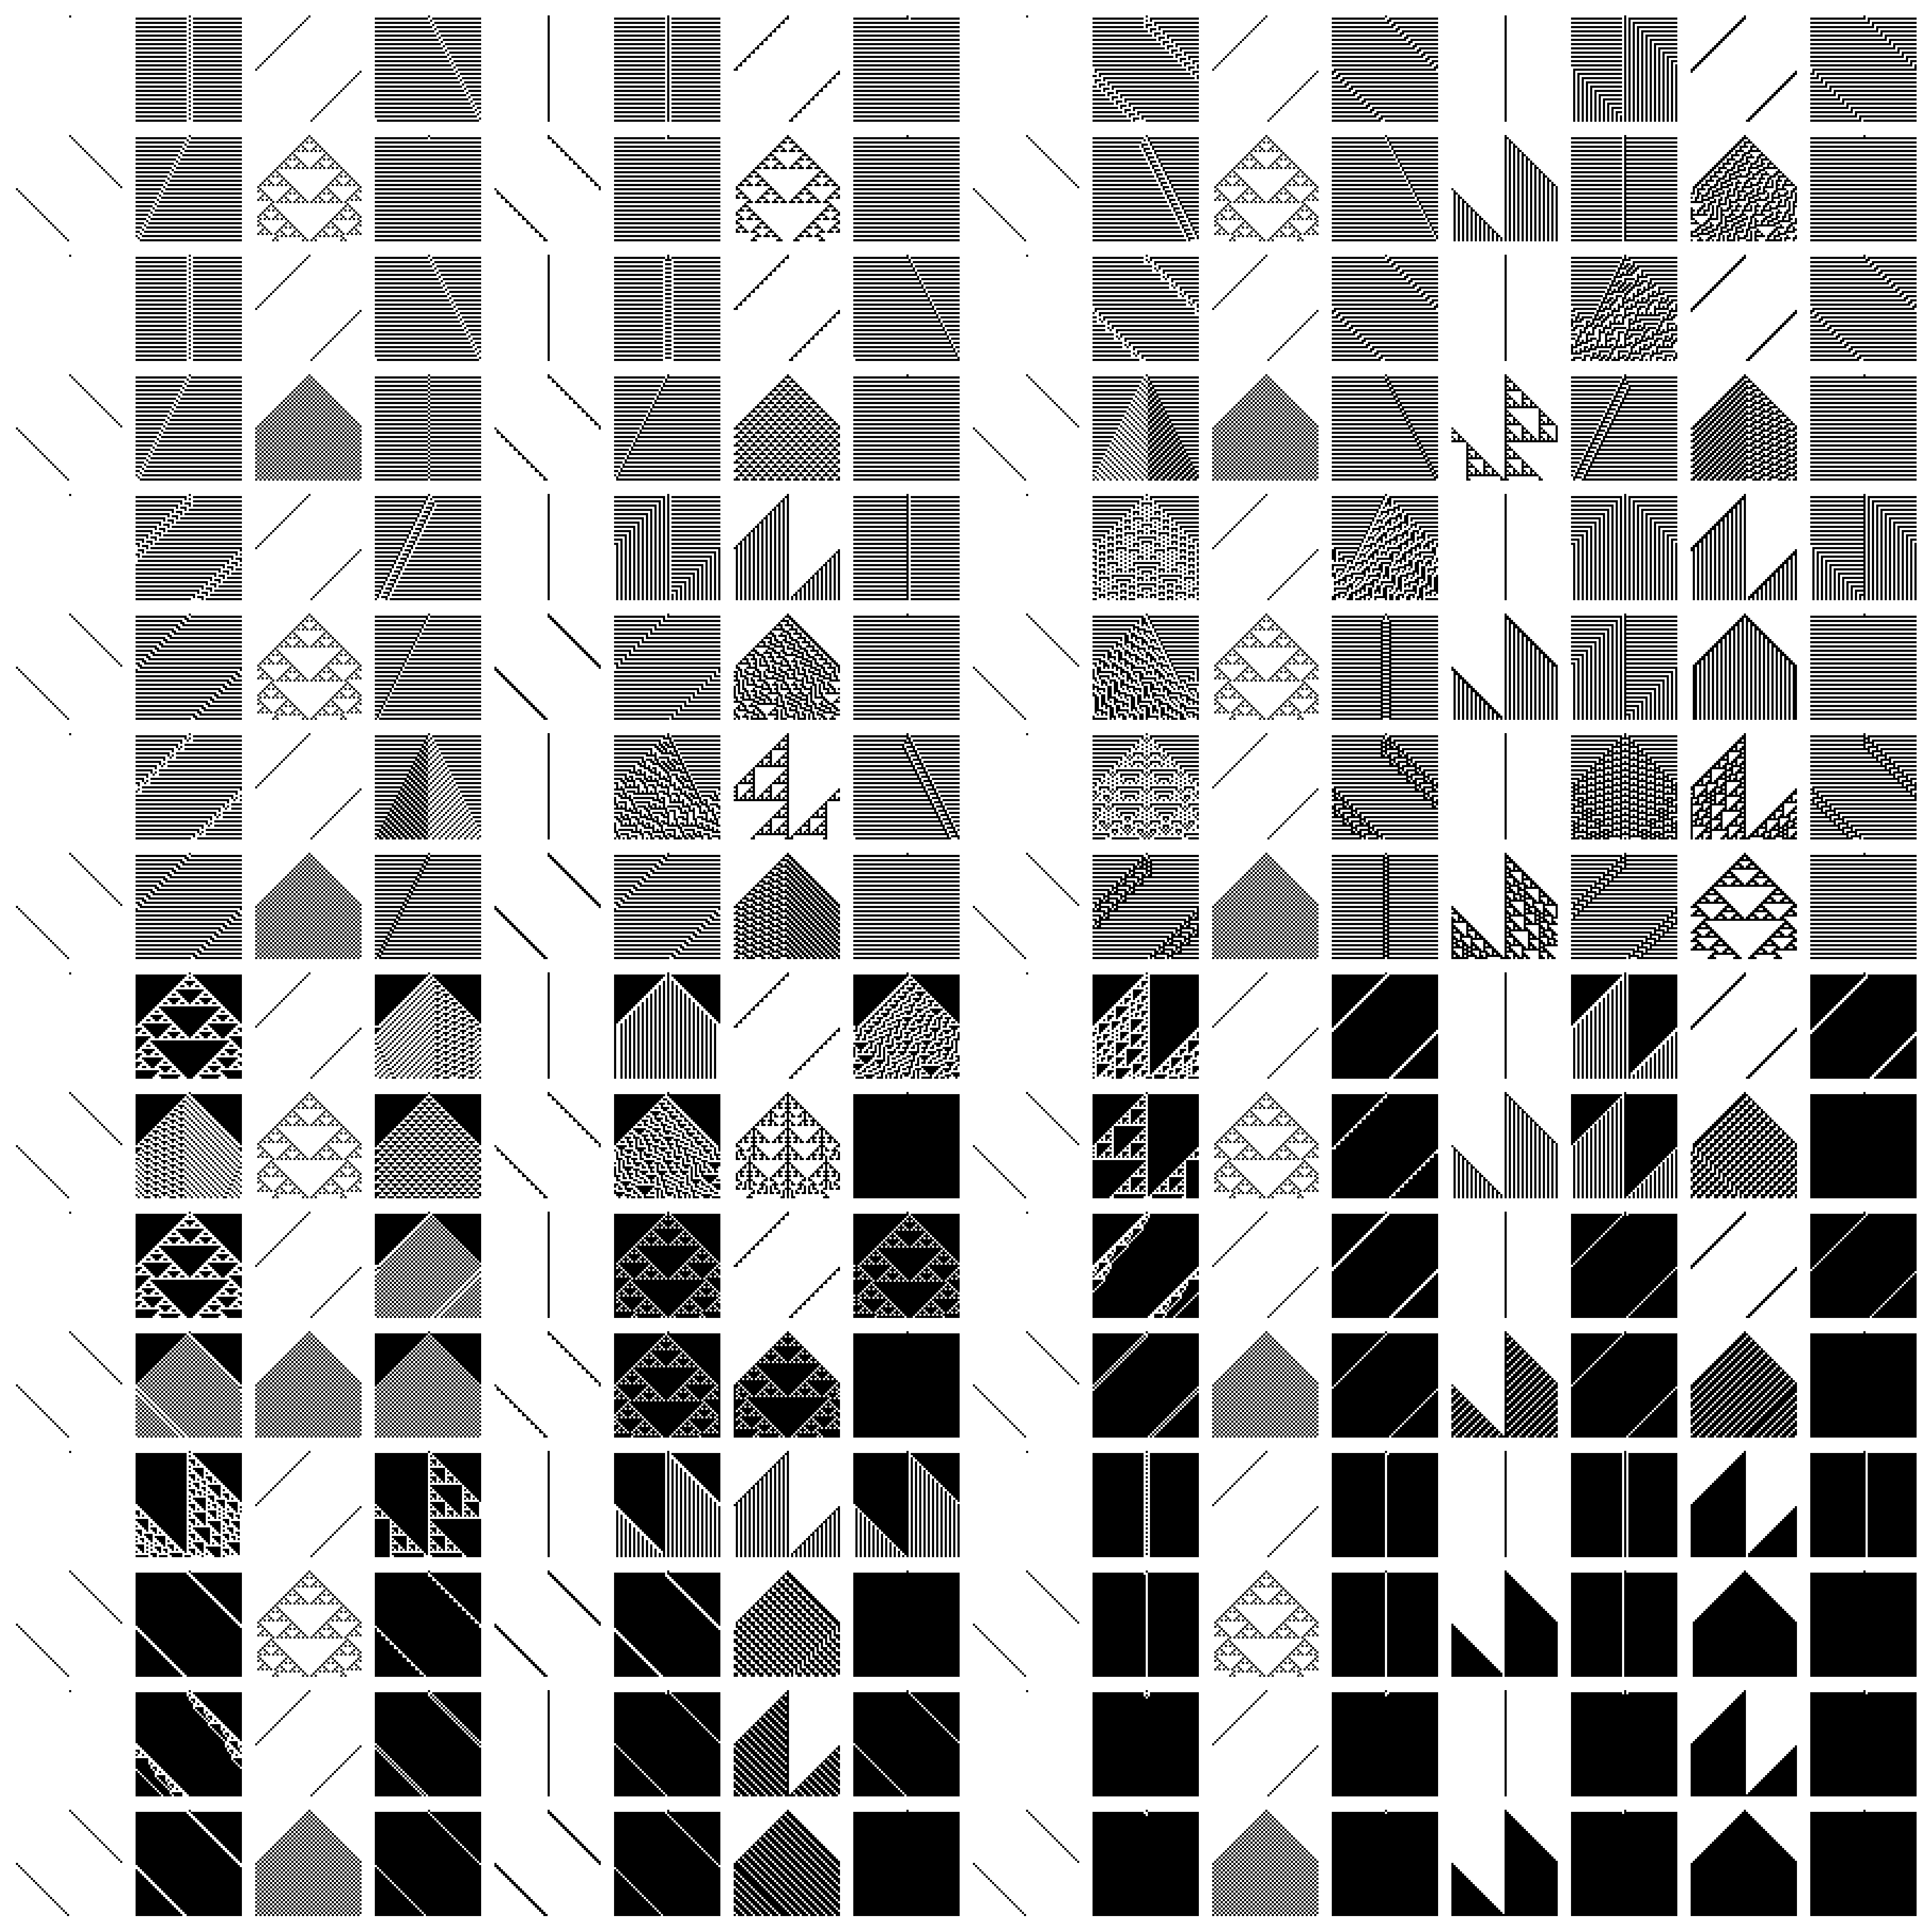

In [6]:
# Gallery of CA
n = 50
initial_state = np.zeros(n, int)
initial_state[n//2] = 1
#initial_state = rng.randint(0,2,n)
plt.subplots(16,16,figsize=(12,12), sharex=True, sharey=True, constrained_layout=True)
for i in range(0,16):
    for j in range(0,16):
        r = i*16+j
        ax = plt.subplot(16,16,r+1)
        ax.axis(False)
        ax.matshow(CA(r, initial_state, n))
plt.show()

# Wolfram classification

Wolfram classified the elementary CAs in four classes, according to their behavior starting from a random initial configuration. The four classes are:

- Class one: CA that converge towards a fixed point.
- Class two: CA that converge towards a periodic orbit.
- Class three: CA that end up in seemingly random states.
- Class four: CA that create structures that interact in complex ways.

## Class One

CA that converge towards a uniform state (i.e., a _fixed point_). After a few iterations, these CA enter a configuration that never changes.

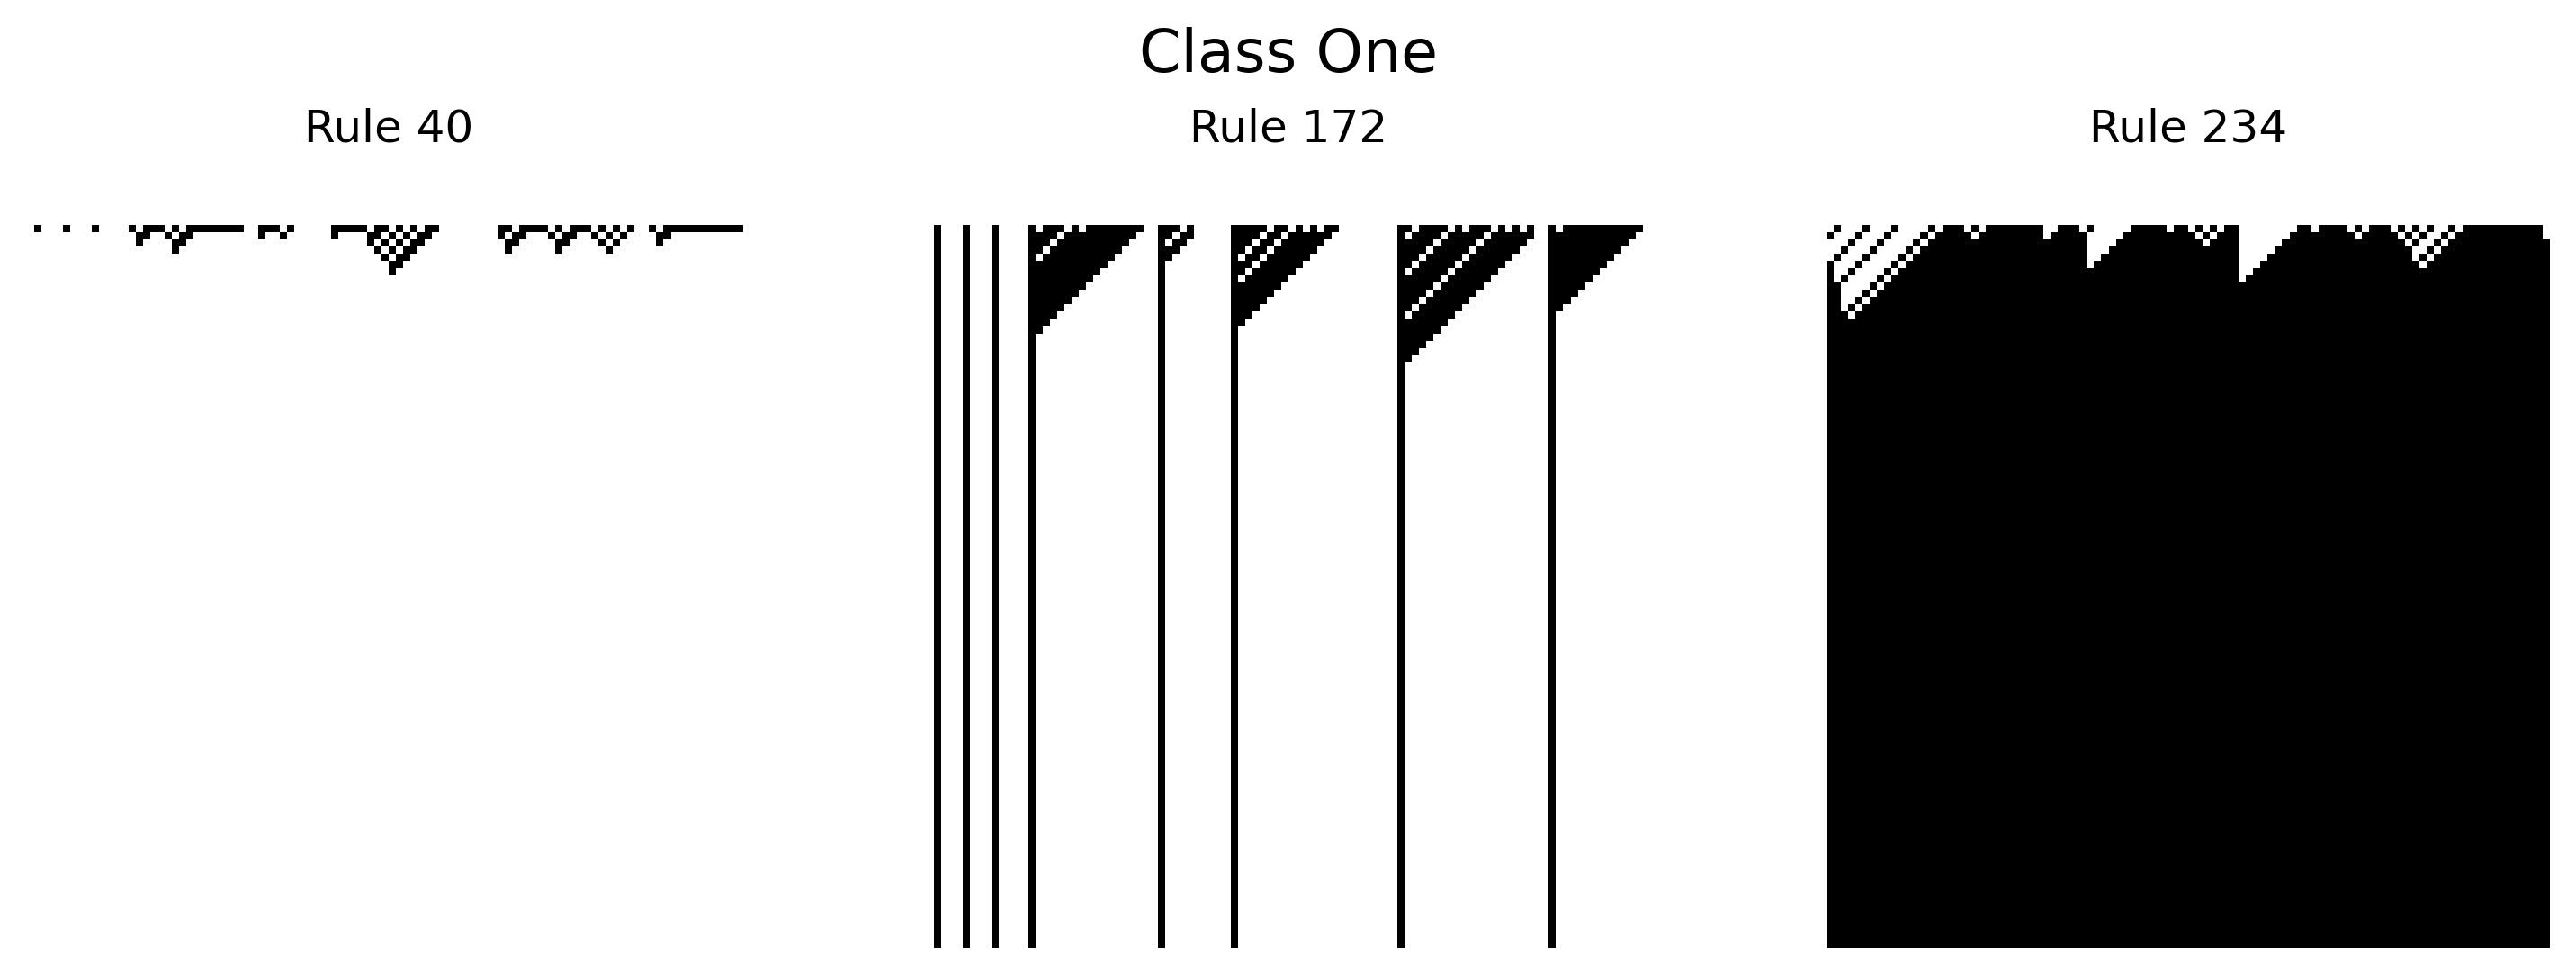

In [7]:
_ = plot_CA_class([40, 172, 234], 'Class One')

## Class Two

Cellular automata which converge to a repetitive state (i.e., _periodic orbit_).

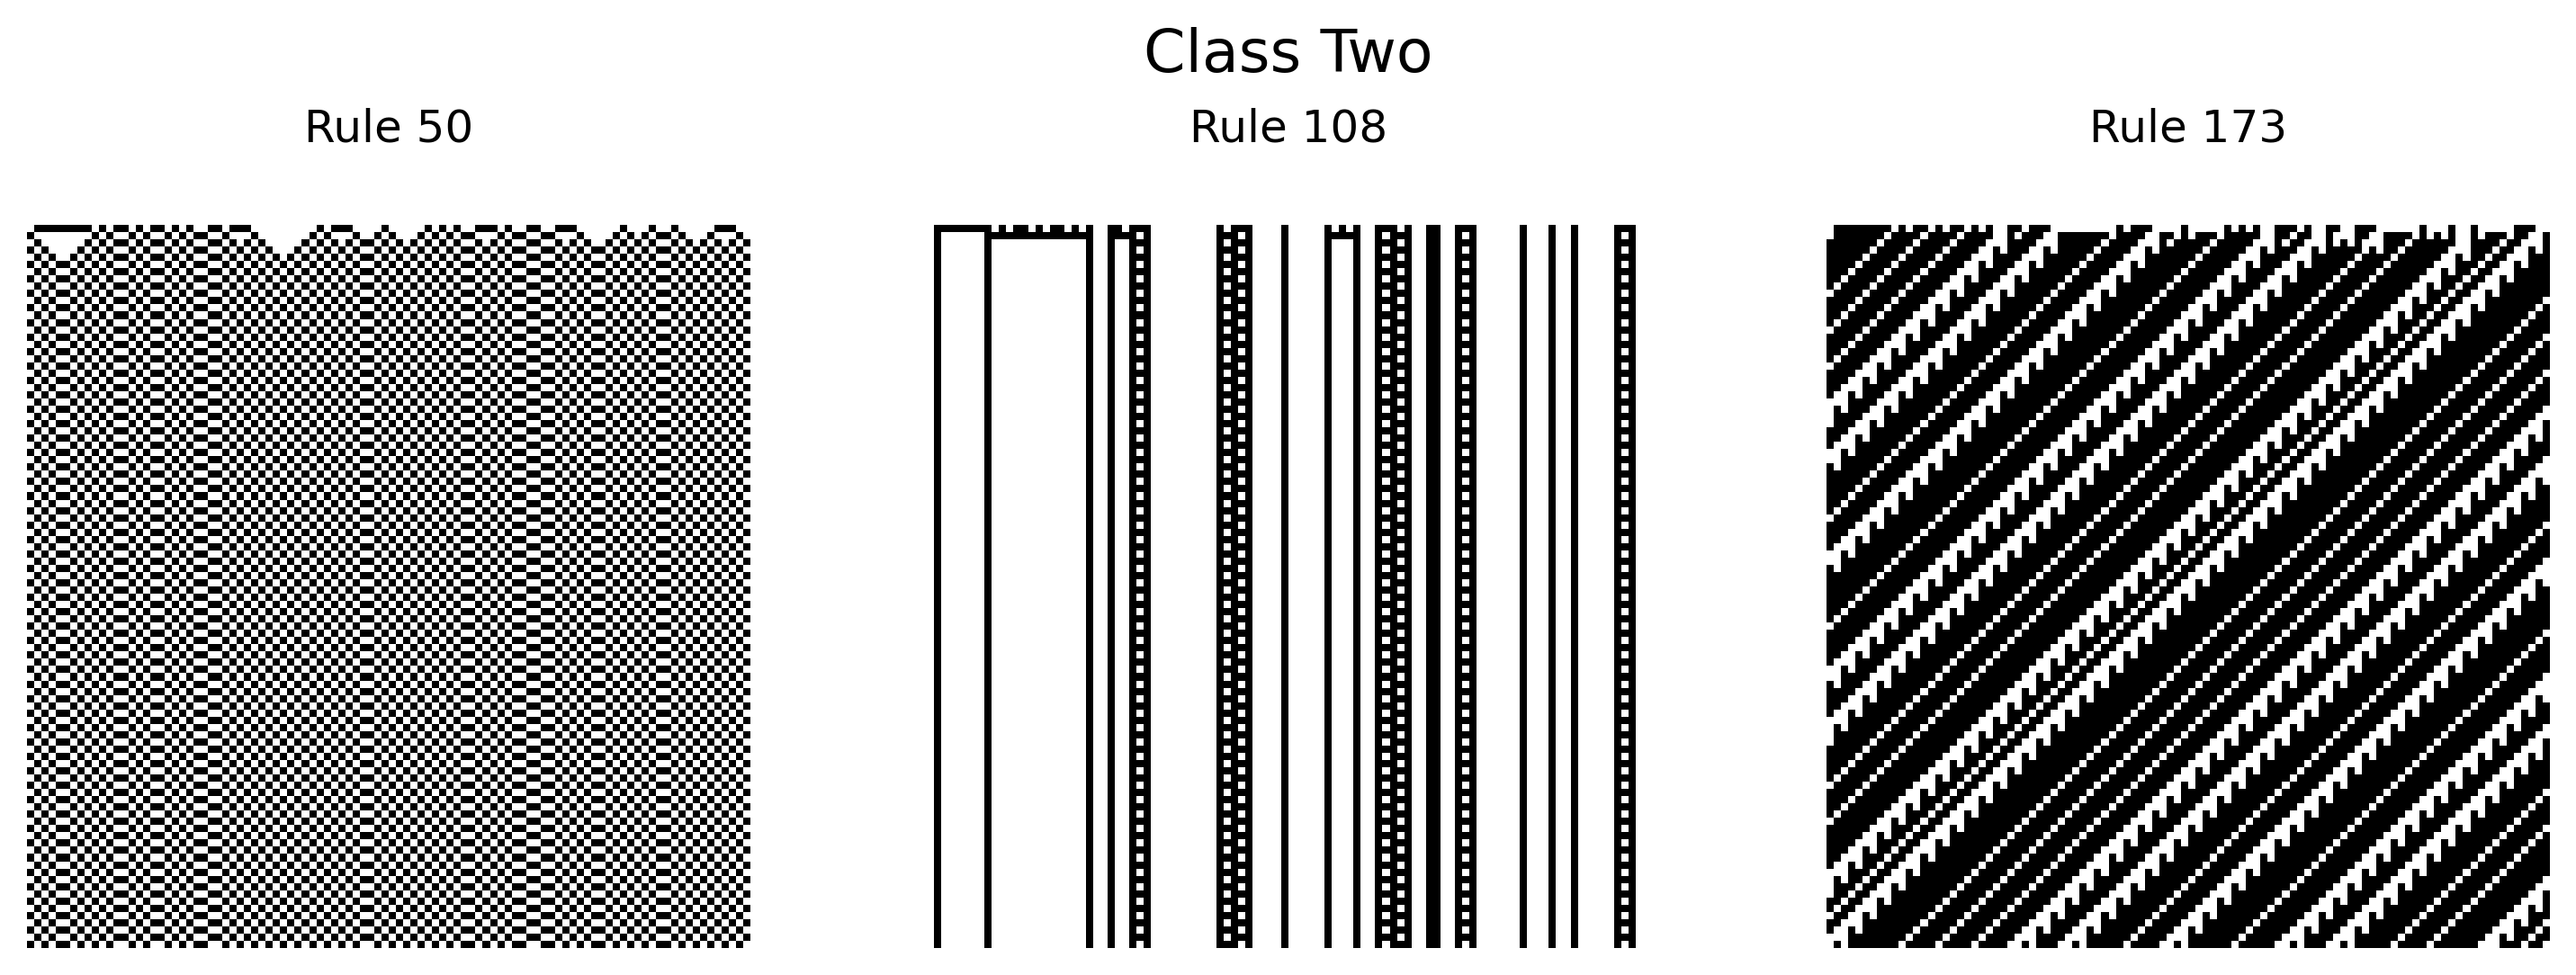

In [8]:
_ = plot_CA_class([50, 108, 173], 'Class Two')

## Class Three

Cellular automata that remain in a random state.

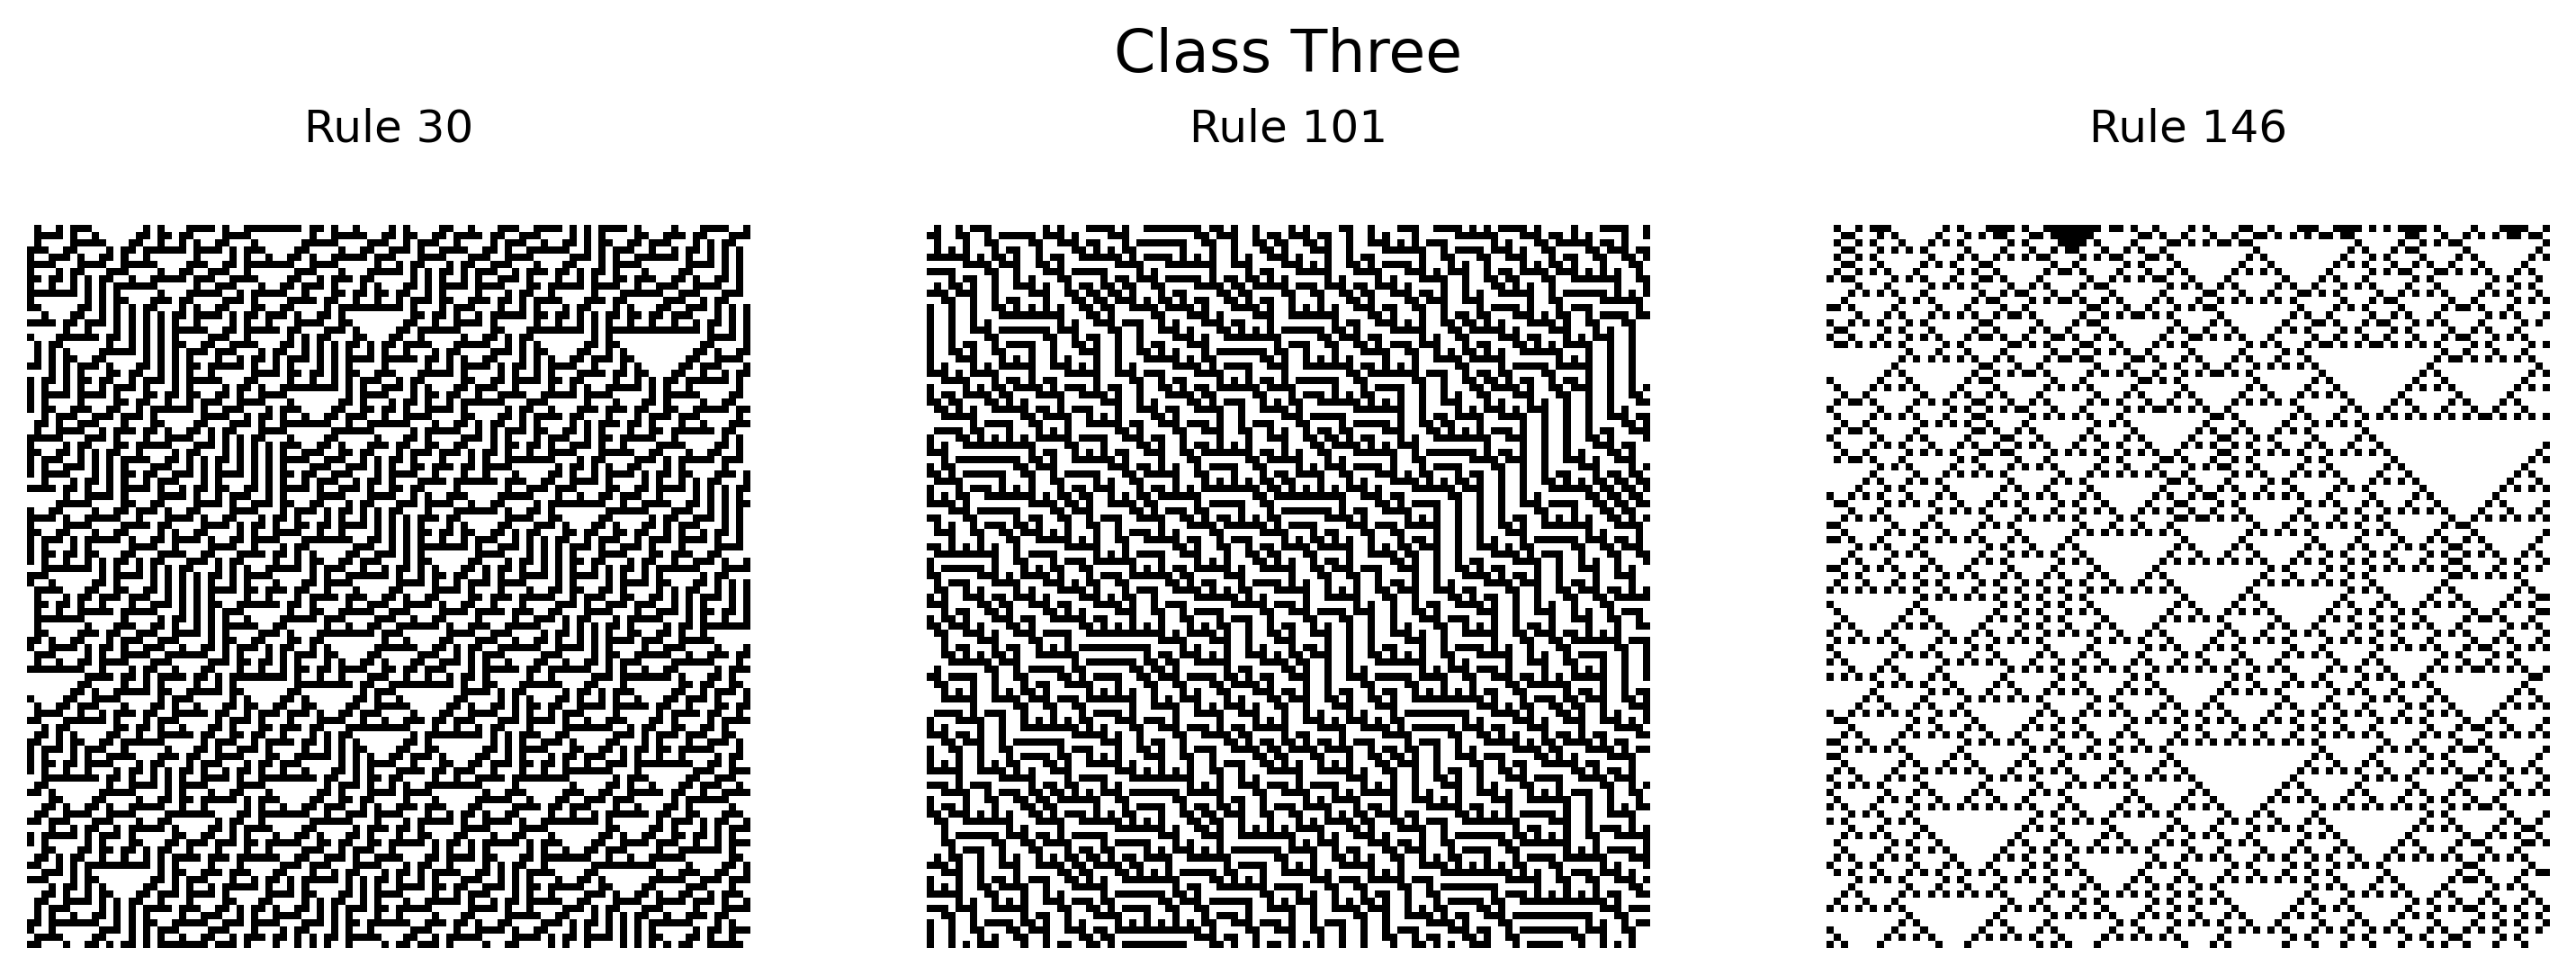

In [9]:
_ = plot_CA_class([30, 101, 146], 'Class Three')

## Class Four

Cellular automata that form areas of repetitive or stable states, but also form structures that interact with each other in complicated ways. This is probably the most interesting class of CA; Matthew Cook proved in 2004 that rule 110 is _Turing complete_. This means that it is possible to encode any Turing Machine into the state space of rule 110 CA, and the evolution of the CA simulates the computation of the TM. Therefore, it would be possible to realize any algorithm using rule 110 CA.

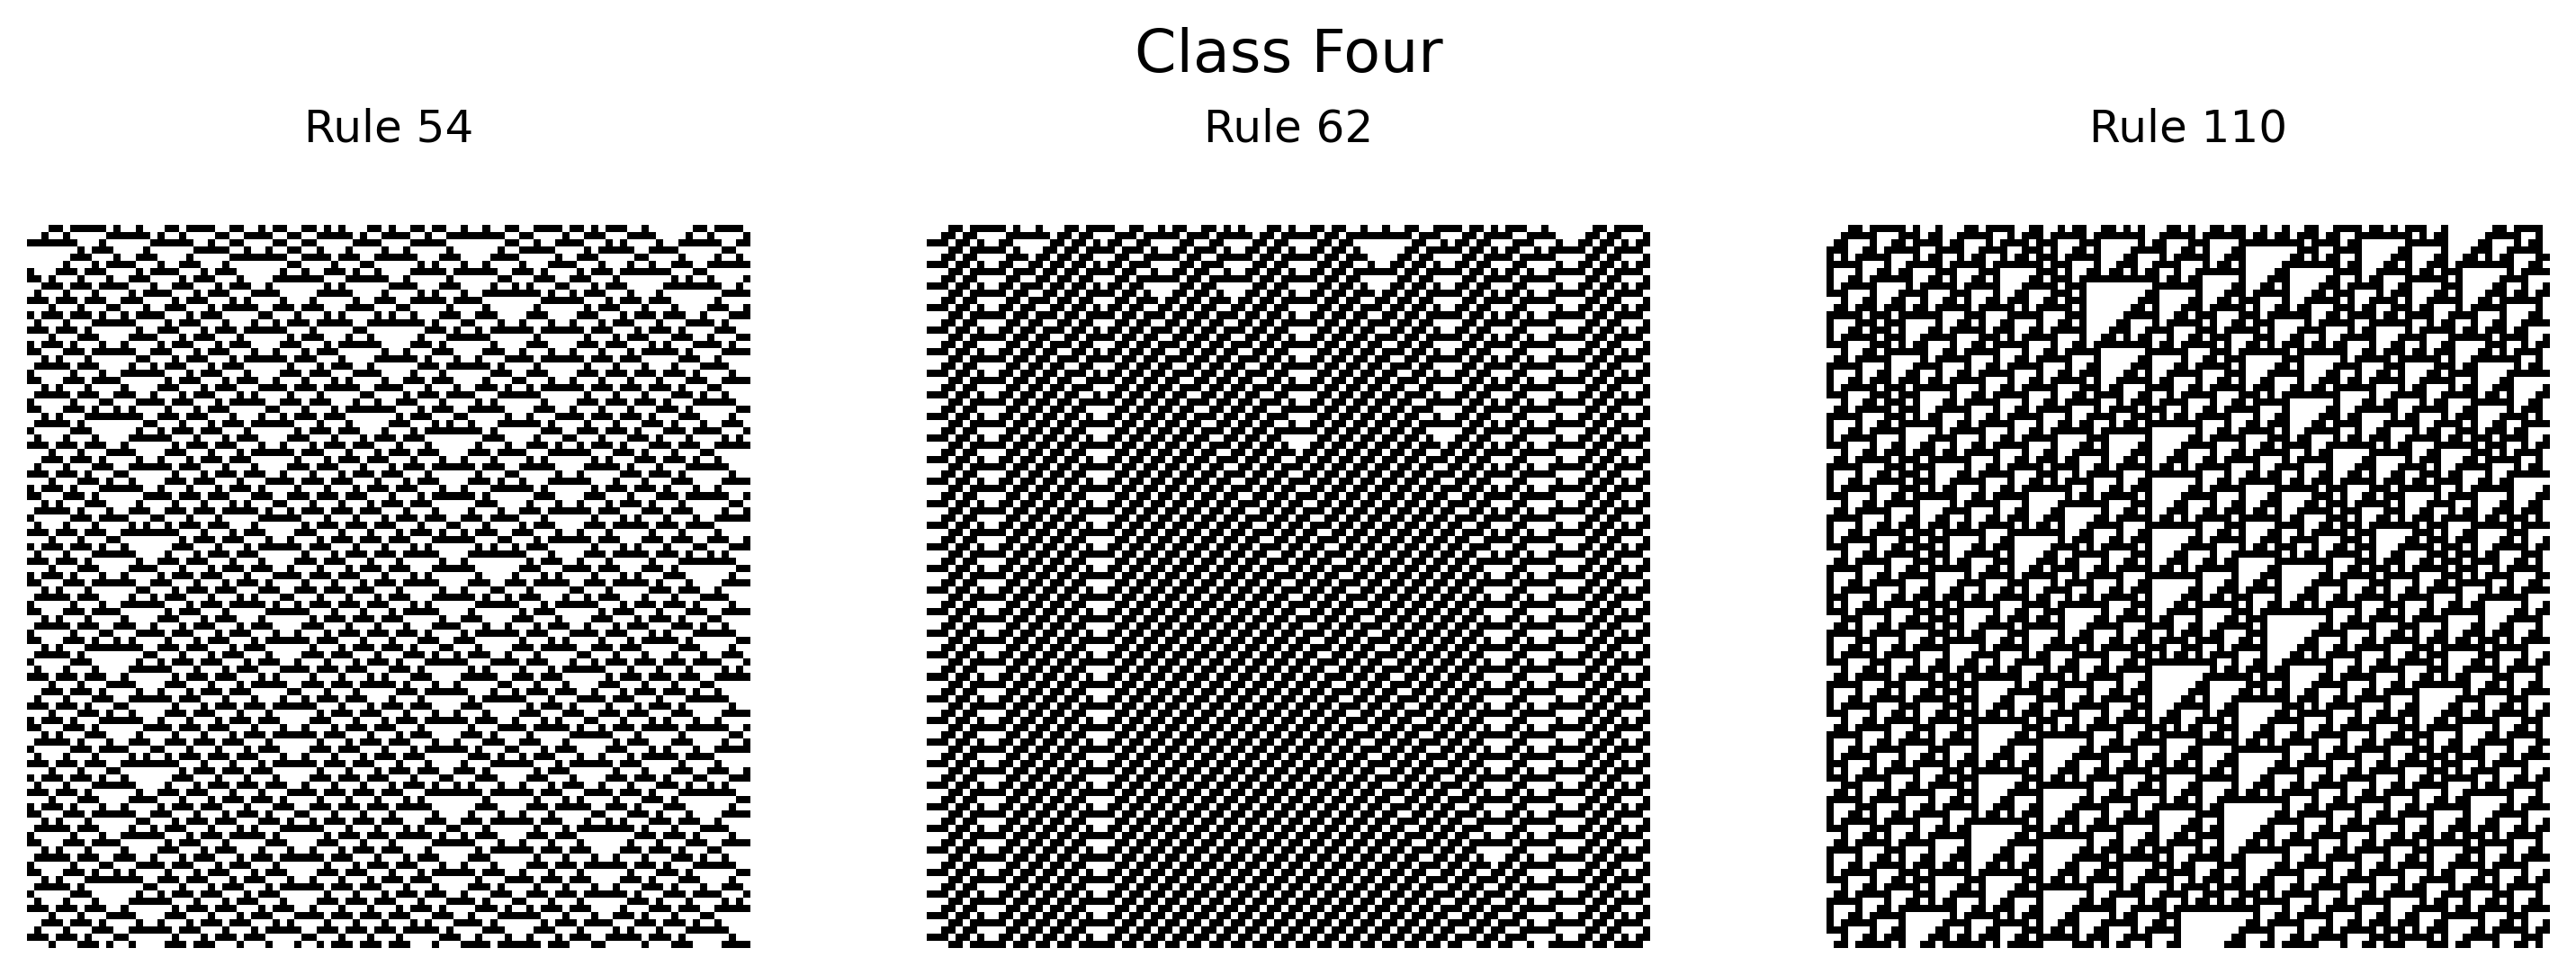

In [10]:
_ = plot_CA_class([54, 62, 110], 'Class Four')

## References

- Eitan Lees, <https://matplotlib.org/matplotblog/posts/elementary-cellular-automata/>
- Stephen Wolfram, _Universality and complexity in cellular automata_, Physica D: Nonlinear Phenomena, Volume 10, Issues 1–2, 1984, Pages 1-35, ISSN 0167-2789, <https://doi.org/10.1016/0167-2789(84)90245-8>. This paper can be downloaded from [Stephen Wolfram's Web site](https://content.wolfram.com/sw-publications/2020/07/universality-complexity-cellular-automata.pdf)
- Matthew Cook, _Universality in Elementary Cellular Automata_, Complex Systems, Volume 15, Issue 1 (2004), <https://doi.org/10.25088/ComplexSystems.15.1.1>. Proves that rule 110 CA is Turing-complete.